# 内置数据结构
## 列表推导

In [22]:
# 判断线段在第二象限
def filter_line_segments(lines):
    # Implement your function here   
    return [id for id, (x1, y1), (x2, y2) in lines if ((x1 != 0 or x2 != 0) and (y1 != 0 or y2 != 0) and (x1 <= 0 and y1 >= 0 and x2 <= 0 and y2 >= 0))]

lines = [(1, (2, 4), (1, 9)), (2, (-2, 4), (-1, 9)), (3, (-2, -4), (-1, -9))]
print(filter_line_segments(lines))

[2]


## 堆栈和队列

In [ ]:
# 前缀转换为后缀
from collections import deque

def postfix(prefix):
    stack = deque()
    prefix = ''.join(reversed(prefix)) # '+AB' => 'BA+'

    for symbol in prefix:
        if symbol != '+' and symbol != '-' and symbol != '*' and symbol != '/':
            stack.append(symbol)
        else:
            o1 = stack.pop()
            o2 = stack.pop()
            stack.append(o1 + o2 + symbol)
    
    return stack.pop()

prefix = '+AB'
print(postfix(prefix))

AB+


## Set和字典

In [ ]:
# 用字典计数
from collections import defaultdict
from collections import OrderedDict

def count_letters(message):
    d = defaultdict(int)
    for letter in message:
        d[letter] += 1

    return OrderedDict(sorted(d.items(), key = lambda t : (t[1], t[0])))

message = 'Welcome to Educative'
print(count_letters(message))

OrderedDict({'E': 1, 'W': 1, 'a': 1, 'd': 1, 'i': 1, 'l': 1, 'm': 1, 'u': 1, 'v': 1, ' ': 2, 'c': 2, 'o': 2, 't': 2, 'e': 3})


# 函数编程
## 封装器 闭包 可选参数

In [ ]:
# 解码信息
def decode(func):
   def wrapper(message):
      # Write your implementation here
      message = sorted(func(message))
      for index in range(0, len(message)):
         n = 0 - (int(message[index]) - 9)
         message[index] = str(n)
      s = ""
      return s.join(message)
   return wrapper

@decode
def clean_message(message):
   # Write your implementation here
   return [x for x in message if x.isdigit()]

print(clean_message('`-hjefh83 njdf83 232'))

7766611


## 匿名函数

In [ ]:
# 阶乘的平方
def factorial(n):
    # Write your implementation here
    if n == 1 or n == 0:
        return 1
    return n * factorial(n - 1)

def square_factorial(n):
    # Write your implementation here
    return [(lambda a : a * a)(x) for x in (list(map(factorial, range(n))))]


square_factorial(6)

[1, 1, 4, 36, 576, 14400]

## 函数对象

In [21]:
class Course1: # Contains implementation of __call__ method
    def __init__(self, name):
        self.name = name

    def __call__(self):
        print(self.name + ' is called')

class Course2: # Contains no implementation of __call__ method
    def __init__(self, name):
        self.name = name


c1 = Course1('Python 3: An In-Depth Exploration')
c2 = Course2('Learn Python from Scratch')
print(callable(c1)) 
print(callable(c2))

True
False


## Case

In [29]:
import csv
from collections import namedtuple, defaultdict, Counter

# 加载数据
with open('food.csv', newline='') as f:
    reader = csv.reader(f)
    data = list(reader)     # contains the data in raw format

# print(data)

# Columns you'll deal with in this project
required_columns = ['GPA', 'Gender', 'drink', 'exercise', 'fries', 'income', 'sports', 'weight']

"""
根据列分组数据
 orig_data：源数据
 req_col：目标列
 kwargs：数据量
采用namedtuple实现
"""
def group_values_with_columns(orig_data, req_col, **kwargs):
    Student = namedtuple('Student', 'GPA Gender drink exercise fries income sports weight')
    columns_index = [orig_data[0].index(name) for name in req_col]

    if kwargs:
        individuals = orig_data[1:kwargs['n'] + 1]
    else:
        individuals = orig_data[1:51]
    
    group_data = []

    for individual in individuals:
        value = [individual[i] for i in columns_index]
        group_data.append(Student._make(value))
    
    return group_data

# test
grouped_data = group_values_with_columns(data, required_columns, n=60)
# for entry in grouped_data:
#     print(entry)

# 获取人数的封装器
def count(func):
    def wrapper(*args):
        result = func(*args)
        result = len(result)
        return result
    return wrapper

# 获取女性人数
@count
def get_females(data):
    return [entry for entry in data if entry.Gender == '1']

# 获取男性人数
@count
def get_males(data):
    return [entry for entry in data if entry.Gender == '2']

# 统计喝饮料的人数
def drink_stats(data):
    d = defaultdict(int)
    for entry in data:
        d[entry.drink] += 1
    
    return d

# test
print(drink_stats(grouped_data))

# 收集锻炼数据
def exercise_stats(data, x):
    temp = [entry for entry in data if entry.exercise == x]
    return get_males(temp), get_females(temp)

# test
print(exercise_stats(grouped_data, '2'))

# 麦当劳薯条的人数
Mcdonalds_fries = count(lambda my_data: [entry for entry in my_data if entry.fries == '1'])

print(Mcdonalds_fries(grouped_data))

# 学生信息统计
bright_students = lambda my_data: [entry for entry in my_data if entry.GPA > '3' and (entry.income =='5' or entry.income == '6')]

students = bright_students(grouped_data)
for entry in students:
    print(entry)

# 收集体重数据
def weight_stats(data, x):
    d = defaultdict(int)
    for entry in data:
        if entry.weight.isnumeric():
            d[entry.weight] += 1
    
    c = Counter(d)
    most = c.most_common(x)
    mweight_result = [i[0] for i in most]
    least = c.most_common()[:-x-1:-1]
    lweight_result = [i[0] for  i in least]

    # 2ND IMPLEMENTATION
    # most_common_weight = [key for key in d if d[key] == max(d.values()) ]
    # least_common_weight = [key for key in d if d[key] == min(d.values()) ] 

    return get_females([entry for entry in data if entry.weight in mweight_result]), get_males([entry for entry in data if entry.weight in lweight_result])

print(weight_stats(grouped_data, 2))

defaultdict(<class 'int'>, {'1': 30, '2': 29, 'nan': 1})
(7, 8)
54
Student(GPA='3.3', Gender='1', drink='1', exercise='2', fries='1', income='6', sports='2', weight="I'm not answering this. ")
Student(GPA='3.2', Gender='1', drink='2', exercise='3', fries='2', income='6', sports='2', weight='Not sure, 240')
Student(GPA='3.5', Gender='1', drink='2', exercise='1', fries='1', income='6', sports='1', weight='190')
Student(GPA='3.3', Gender='1', drink='2', exercise='2', fries='1', income='5', sports='2', weight='137')
Student(GPA='3.3', Gender='1', drink='1', exercise='nan', fries='1', income='5', sports='2', weight='180')
Student(GPA='3.904', Gender='1', drink='1', exercise='1', fries='1', income='5', sports='1', weight='110')
Student(GPA='3.4', Gender='2', drink='2', exercise='3', fries='1', income='5', sports='1', weight='264')
Student(GPA='3.6', Gender='1', drink='2', exercise='2', fries='1', income='5', sports='1', weight='123')
Student(GPA='3.1', Gender='2', drink='2', exercise='2', fr

In [28]:
def gpa_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.GPA.replace('.', '1').isnumeric()]
        return result
    return wrapper


def gender_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.Gender == '1' or entry.Gender =='2']
        return result
    return wrapper


def drink_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.drink == '1' or entry.drink =='2']
        return result
    return wrapper


def exercise_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        l = ['1', '2', '3', '4', '5']
        result = [entry for entry in result if entry.exercise in l]
        return result
    return wrapper


def fries_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.fries == '1' or entry.fries =='2']
        return result
    return wrapper


def income_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        l = ['1', '2', '3', '4', '5', '6']
        result = [entry for entry in result if entry.income in l]
        return result
    return wrapper


def sports_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.sports == '1' or entry.sports=='2']
        return result
    return wrapper


def weight_cleaner(func):
    def wrapper(*args):
        result = func(*args)
        result = [entry for entry in result if entry.weight.isnumeric()]
        return result
    return wrapper

# 清理数据
@weight_cleaner
@sports_cleaner
@income_cleaner
@fries_cleaner
@exercise_cleaner
@drink_cleaner
@gender_cleaner
@gpa_cleaner
def clean_data(data):
    return data

cleaned_data = clean_data(grouped_data)

# 面向对象
## =，==和is运算符之间的比较

| operator | meaning | example |
| ------ | ------------------------- | --------------- |
| + | It adds two operands together, or acts as a sign for a single operand. | 5 + 2 = 7 or +2 (sign) |
| - | It subtracts two operands or acts as a sign for a single operand. | 5 - 2 = 3 or -2 (sign) |
| * | It multiplies two operands. | 5 * 2 = 10 |
| / | It divides two operands. | 10 / 5 = 2 |
| % | It returns a remainder after dividing two operands. | 5 % 2 = 1 |

----------------------------------------------------------------------------------------------------------------------

| relational operator | name | example |
| ------ | ------- | ----------|
| == | Equal | 5 == 5 |
| != | Not Equal | 6 != 5 |
| > | Greater than | 6 > 5 |
| < | Less Than | 5 < 6 |

---------------------------------------------------------------------------------------------------------------------------

| logical opeartor | meaning | example |
| ------ | -------------------| --------------- |
| AND | It returns true if both of the statements are true. | x > 5 and y < 15 |
| OR | It returns true if either one of the statements is true. | x > 5 and y < 15 | 
| NOT | It reverses the result, for true it returns false | not(x > 5) |


In [ ]:
x = [1, 2, 3]
y = x

x.append(4) # 相同引用，所以y也会同步更改
print(x)
print(y)

print(x == y) # 列表相同，结果为true
print(x is y) # x，y是相同引用，结果为true

y = list(x) # y与x将是不同的列表
print(x == y)
print(x is y) # False

[1, 2, 3, 4]
[1, 2, 3, 4]
True
True
True
False


## 深拷贝和浅拷贝

浅拷贝

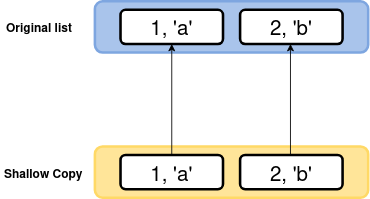

深拷贝

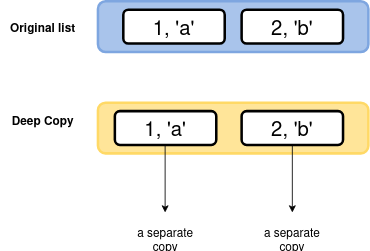

In [32]:
import copy

# Creating a custom class
class Person:
    def __init__(self, parents, siblings):
        self.parents = parents
        self.siblings = siblings

# Creating objects of Person class
person1 = Person(['Kim', 'Marry'], ['Joey', 'Katherine', 'Chris'])
person2 = copy.copy(person1)        # Shallow copy
person3 = copy.deepcopy(person1)    # Deep copy

# Verifying shallow copy
print(person2 is person1)
person1.siblings.append('Tim')
print(person2.siblings)

# Verifying deep copy
print(person3 is person1)
print(person3.siblings)

False
['Joey', 'Katherine', 'Chris', 'Tim']
False
['Joey', 'Katherine', 'Chris']


## 引用传递

In [33]:
def function(x, y):
    x += y
    return x

x = 1
y = 2
function(x, y)  # Calling for ints
print(x)

x = [1, 2]
y = [3, 4]
function(x, y)  # Calling for lists
print(x)

x = (1, 2)
y = (3, 4)
function(x, y)  # Calling for tuples
print(x)

1
[1, 2, 3, 4]
(1, 2)


## 异常类

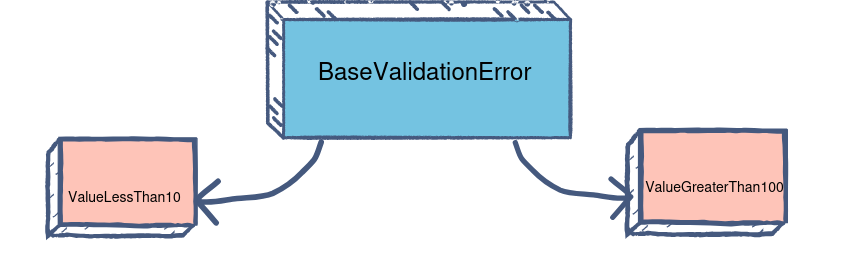

In [ ]:
class BaseValidationError(ValueError):
    pass

class ValueLessThan10(BaseValidationError):
    pass

class ValueGreaterThan100(BaseValidationError):
    pass

def validate(num):
    if num < 10:
        raise ValueLessThan10(num)
    elif num > 100:
        raise ValueGreaterThan100(num)

# validate(2)

ValueLessThan10: 2

## 类变量和实例变量

| 类变量 | 实例变量 |
| ---------------------------- | ---------------------------- |
| 在类定义中声明且不与任何实例绑定的变量称为类变量 。| 与特定对象实例绑定的变量称为实例变量 。|
| 它将内容存储在类本身上。|它将内容存储在从类创建的每个对象上，而不是类本身上。|
| 从特定类创建的所有对象共享对同一组类变量的访问权限。| 实例变量的内容对于不同的实例而言是独立的。|
| 修改类变量会同时影响所有对象实例。| 修改实例变量一次仅影响一个对象实例。|

In [ ]:
class Course:
    language = 'Python' # class variable

    def __init__(self, level):
        self.level = level # instance variable

c1 = Course('beginner')
c2 = Course('intermediate')

print(c1.language, ",", c1.level)
print(c2.language, ",", c2.level)
print(Course.language)
# print(Course.level)  # 这里将抛出异常

Python , beginner
Python , intermediate
Python


AttributeError: type object 'Course' has no attribute 'level'

In [ ]:
c1.language = 'Java' # instance c1 will add a new attribute language, it is different from class Course

print('Accessing language via c1 (object): ', c1.language)
print('Accessing language via c2 (object): ',c2.language)
print('Accessing language via Course (class)',Course.language)
print('Accessing language via c1.__class__: ', c1.__class__.language)

Accessing language via c1 (object):  Java
Accessing language via c2 (object):  Python
Accessing language via Course (class) Python
Accessing language via c1.__class__:  Python


## 类，实例，静态方法

In [ ]:
class MyClass:
    def instanceMethod(self):
        return 'instance method called', self
    
    @classmethod
    def classMethod(cls):
        return 'class method called', cls
    
    @staticmethod
    def staticMethod():
         return 'static method called'

obj = MyClass()
print(obj.instanceMethod())
print(obj.classMethod())
print(obj.staticMethod())

# Calling each method on class
print(MyClass.classMethod())
print(MyClass.staticMethod())
# print(MyClass.instanceMethod())

('instance method called', <__main__.MyClass object at 0x78849f40e810>)
('class method called', <class '__main__.MyClass'>)
static method called
('class method called', <class '__main__.MyClass'>)
static method called


TypeError: MyClass.instanceMethod() missing 1 required positional argument: 'self'

## 抽象基类

In [43]:
from abc import ABC, abstractmethod

# Abstract base class
class Base(ABC): 

    @abstractmethod
    def method1(self): 
        pass

    @abstractmethod
    def method2(self): 
        pass

# Concrete subclass
@Base.register         # Registering Base as a class decorator
class Derived(): 
    
    def method1(self): # Implementing method1
        return "method1 is called"

    def method2(self): # Implementing method1
        return "method2 is called"
    
obj = Derived()
print(obj.method1())

method1 is called


## Case

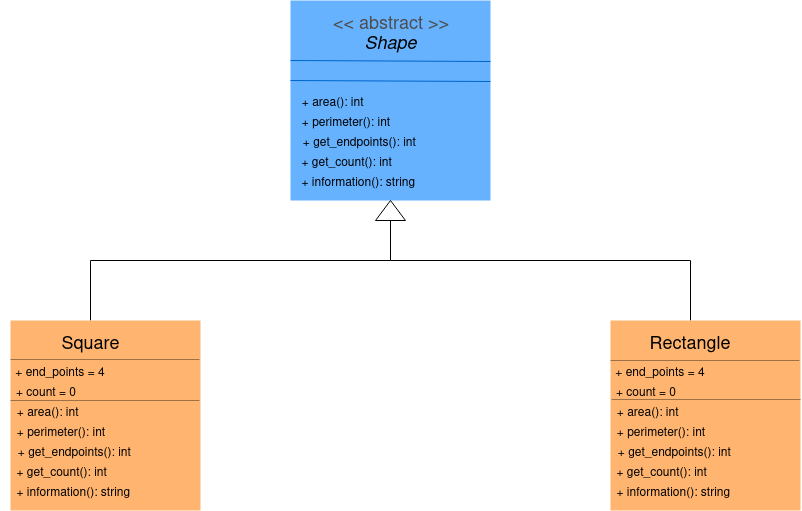

In [44]:
from abc import ABC, abstractmethod

# Abstract class
class Shape(ABC):   # can't make object of Shape

    @abstractmethod
    def area(self):
      pass

    @abstractmethod
    def perimeter(self):
        pass

    @abstractmethod
    def information():
        pass

    @abstractmethod
    def get_endpoints(cls):
        pass

    @abstractmethod
    def get_count(cls):
        return count

# Square class
class Square(Shape):

    # class variables
    end_points = 4
    count = 0

    def __init__(self, l):
        self.length = l
        Square.count += 1

    def area(self):
        return (self.length * self.length)

    def perimeter(self):
        return (4 * self.length)

    @staticmethod
    def information():
        return "Hi! I am a square."

    @classmethod
    def get_endpoints(cls):
        return cls.end_points

    @classmethod
    def get_count(cls):
        return cls.count

# Rectangle class
class Rectangle(Shape):

    # class variables
    end_points = 4
    count = 0

    def __init__(self, l, w):
        self.length = l
        self.width = w
        Rectangle.count += 1

    def area(self):
        return (self.length * self.width)

    def perimeter(self):
        return (2 * self.length) + (2 * self.width)

    @staticmethod
    def information():
        return "Hi! I am a rectangle."

    @classmethod
    def get_endpoints(cls):
        return cls.end_points

    @classmethod
    def get_count(cls):
        return cls.count

# Testing the classes
obj = Square(4)
print(Square.get_count())
print(Square.get_endpoints())
obj1 = Square(2)
obj2 = Rectangle(3, 4)
print(obj2.get_count())
print(Square.information())
print(Rectangle.information())

1
4
1
Hi! I am a square.
Hi! I am a rectangle.


## 运算符重载

* 不允许重载内置类型的运算符。
* 不允许创建新的操作符。
* is,and,or,not不能重载

In [49]:
class Vector():

    def __init__(self, vector):
      self.vector = vector

    def print(self):
      print(list(self.vector))

    # Unary + operator overloading
    def __pos__(self):
        return Vector(self.vector)

    # Binary + operator overloading
    def __add__(self, other):
        return Vector(i+j for i, j in itertools.zip_longest(self.vector, other.vector, fillvalue=0))

    # Scalar multiplication
    def __mul__(self, scalar): 
      try: 
        return Vector(n * scalar for n in self.vector)
      except:
        raise NotImplemented

    def __rmul__(self, scalar): 
      return self * scalar
    
    # Overloading unary - operator
    def __neg__(self):
        return Vector(-x for x in self.vector)

    # Binary - operator overloading
    def __sub__(self, other):
        return Vector(i-j for i, j in itertools.zip_longest(self.vector, other.vector, fillvalue=0))

v1 = Vector([2, 4, -1])
v2 = v1 * 3
v3 = -5 * v1

v2.print()
v3.print()

[6, 12, -3]
[-10, -20, 5]


# 迭代和生成器

In [50]:
# iter
message = 'Hello'
it = iter(message)

while True:
    try:
        print(next(it))
    except StopIteration:
        break

H
e
l
l
o


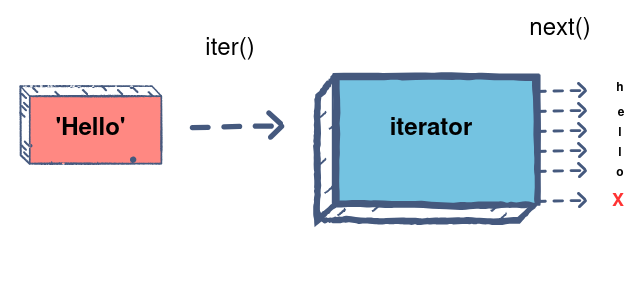

 > 迭代器是实现 __iter__ 和 __next__ dunder 方法的对象。
 >
 >__iter__() 函数返回一个迭代器对象，该对象遍历给定对象的每个元素。而 __next__() 函数返回序列中的下一个元素。

In [52]:
class Counter:
  def __iter__(self):
    self.n = 1
    return self  # Returning an iterator object
 
  def __next__(self):
    if self.n <= 10:
        x = self.n
        self.n += 1
        return x  # Returning next item in the sequence
    else:
       raise StopIteration

count = Counter()
iterator = iter(count)

print(next(iterator))
print(next(iterator))
print(next(iterator))
print(next(iterator))

1
2
3
4


## Case - Create a Fibonacci Iterator

In [53]:
class Fibonacci:
    def __init__(self, n):
        self.limit = n
        self.count = 1
        self.a = 0
        self.b = 1
    
    def __iter__(self):
        return self
    
    def __next__(self):
        if self.count <= self.limit:    # Controlled iterations
            x = self.a
            self.a, self.b = self.b, self.a +self.b # Adding preceding values
            self.count += 1
            return x
        else:
            raise StopIteration

fib = Fibonacci(7)
iterator = iter(fib)

for x in iterator:
  print(x)

0
1
1
2
3
5
8


In [54]:
# Generator function
def Counter():
    a = 1
    while a <= 10:
        yield a
        a += 1

# Using __next__() method
print("Using __next__() method:")
c = Counter()
print(c.__next__())
print(c.__next__())

# Using for loop
print("Using for loop:")
for value in Counter():  
    print(value) 

Using __next__() method:
1
2
Using for loop:
1
2
3
4
5
6
7
8
9
10


In [55]:
def Fibonacci(n):
    a, b = 0, 1
    for _ in range(n):
        yield a, b
        a, b = b, a+b

for num in Fibonacci(7):
    print(num)

(0, 1)
(1, 1)
(1, 2)
(2, 3)
(3, 5)
(5, 8)
(8, 13)


# 协程

In [57]:
import math

def maximum():
  result = - math.inf

  while True:
    value = yield result  # Recieving values

    if value > result:    # Deciding on maximum
      result = value  

coroutine = maximum()
next(coroutine)

# Sending values 
print(coroutine.send(1))
print(coroutine.send(7))
print(coroutine.send(3))
print(coroutine.send(10))
print(coroutine.send(5))
print(coroutine.send(8))
print(coroutine.send(12))

coroutine.close() # Closing coroutine 

1
7
7
10
10
10
12


In [58]:
from functools import wraps

def coroutine(func):
  @wraps(func)
  def primer(*args, **kwargs):
    generator = func(*args, **kwargs)
    next(generator)
    return generator
  return primer


@coroutine
def maximum():
  result = int()

  while True:
    value = yield result  # Recieving values

    if value > result:    # Deciding on maximum
      result = value  

cr = maximum()

# Sending values 
print(cr.send(1))
print(cr.send(7))
print(cr.send(3))
print(cr.send(10))
print(cr.send(5))
print(cr.send(8))
print(cr.send(12))

cr.close() # Closing coroutine 

1
7
7
10
10
10
12


## Case - Matrix

In [63]:
class Matrix:
    def __init__(self, matrix):
        self.matrix = matrix

    def print(self):
        print(self.matrix)
    
    def __add__(self, other):
        try:
            rows_m1 = len(self.matrix)
            rows_m2 = len(other.matrix)
            cols_m1 = [len(self.matrix[0])]
            cols_m2 = [len(other.matrix[0])]

            if rows_m1 == rows_m2:
                if cols_m1 == cols_m2:
                    return Matrix([[col_m1 + col_m2 for (col_m1, col_m2) in zip(row_m1, row_m2)] for (row_m1, row_m2) in zip(self.matrix, other.matrix)])
                else:
                    raise ValueError('Number of columns is different')
            else:
                raise ValueError('Number of rows is different')
        except:
            raise ValueError('Not a matrix')
    
    def __mul__(self, other):
        if type(other) == int:
            return Matrix([[other * i for i in n] for n in self.matrix])
        try:
            rows_m1 = len(self.matrix)
            rows_m2 = len(other.matrix)
            cols_m1 = len(self.matrix[0])
            cols_m2 = len(other.matrix[0])

            if cols_m1 == rows_m2: 
                return Matrix([[sum(a*b for a,b in zip(row_m1,col_m2)) for col_m2 in zip(*other.matrix)] for row_m1 in self.matrix])               
            else:
                raise ValueError('Order not correct')
        except:
            raise ValueError

    def __rmul__(self, other):
        return self * other

In [64]:
import contextlib

# Generator function decorated
@contextlib.contextmanager
def readFile(filename, mode):
    
    #WRITE YOUR CODE HERE
    myfile = open(filename, mode)

    yield myfile

    myfile.close()                # Executed after the block

# Reading matrix from file
def read_matrix(filename):
    matrix = []
    #WRITE YOUR CODE HERE
    with open(filename, 'r') as fp:
        for line in fp:
            matrix.append([int(num) for num in line.split()])
    return matrix


# Reading matrices
matrix1 = Matrix(read_matrix('matrix1.txt'))
matrix2 = Matrix(read_matrix('matrix2.txt'))

matrix1.print()
matrix2.print()

# Priming a coroutine
def coroutine(func):  
    @wraps(func)
    def primer(*args, **kwargs):
        generator = func(*args, **kwargs)
        next(generator)
        return generator
    return primer

@coroutine
def add_series():
    result = Matrix(None)
    while True:
        curr_matrix = yield result
        if result.matrix is None:
            result.matrix = curr_matrix.matrix
        else:
            try:
                result = curr_matrix + result
            except:
                yield None

@coroutine
def multiply_series():
    result = Matrix(None)
    while True:
        curr_matrix = yield result
        if result.matrix is None:
            result.matrix = curr_matrix.matrix
        else:
            try:
                result = curr_matrix * result
            except:
                yield None

def switch():
    matrix = yield
    return matrix * matrix

@coroutine
def switch_add_multiply():
    result = Matrix(None)
    while True:
        curr_matrix = yield from switch()
        if result.matrix is None:
            result.matrix = curr_matrix.matrix
        else:
            try:
                result = curr_matrix + result
            except:
                print('Order not correct')

cr = switch_add_multiply()
cr.send(matrix1)
cr.send(matrix2)
cr.close()

@coroutine
def intensify_magnitude(matrix):
    result = matrix
    while True:
        value = yield result
        try:
            result = result * value # Multiplying previout result with value
        except:
            print('Multiplication not possible')

cr = intensify_magnitude(matrix1)
cr.send(2)
cr.send(3)
cr.close()

[[1, 2], [3, 4]]
[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]]
Order not correct
